# Assignment 03: Data Cleaning & Preprocessing Techniques

## Aim

To handle missing values, detect and treat outliers, and scale/encode features in an automotive dataset.

## Techniques Used

1. Missing value imputation
2. IQR-based outlier detection
3. Outlier capping
4. One-Hot Encoding
5. StandardScaler

## Final Goal

Convert a messy automotive dataset into a clean, numerical, model-ready dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
np.random.seed(42)

n = 300

mileage = np.random.uniform(
    5000,
    150000,
    n
)

age = np.random.uniform(
    1,
    15,
    n
)

engine = np.random.uniform(
    1.0,
    4.0,
    n
)

price = (
    30000
    - age * 1500
    - mileage * 0.08
    + engine * 3000
    + np.random.normal(0, 1500, n)
)

price = np.clip(
    price,
    2000,
    None
)

fuel = np.random.choice(
    [
        "Petrol",
        "Diesel",
        "Electric"
    ],
    n
)

messy = pd.DataFrame({
    "mileage_km": mileage,
    "age_years": age,
    "engine_size_L": engine,
    "fuel_type": fuel,
    "price": price
})

messy.head()

,mileage_km,age_years,engine_size_L,fuel_type,price
0,59308.317233,1.723544,1.506805,Electric,27679.633578
1,142853.574429,8.438965,1.835771,Diesel,9543.909469
2,111139.121563,8.568892,1.531031,Diesel,14234.667608
3,91805.480209,9.924019,1.266108,Diesel,11290.503251
4,27622.702864,11.165279,1.361908,Diesel,14343.904072


In [3]:
missing_indices = np.random.choice(
    n,
    15,
    replace=False
)

messy.loc[
    missing_indices[:5],
    "mileage_km"
] = np.nan

messy.loc[
    missing_indices[5:10],
    "age_years"
] = np.nan

messy.loc[
    missing_indices[10:13],
    "engine_size_L"
] = np.nan

messy.loc[
    missing_indices[13:],
    "fuel_type"
] = np.nan

In [4]:
messy.loc[
    0,
    "price"
] = 200000

messy.loc[
    1,
    "price"
] = 250000

messy.loc[
    2,
    "mileage_km"
] = 500000

messy.loc[
    3,
    "mileage_km"
] = 600000

In [5]:
print("Missing values before cleaning:")

print(
    messy.isna().sum()
)

print("\nDataset description:")

display(
    messy.describe()
)

Missing values before cleaning:
mileage_km       5
age_years        5
engine_size_L    3
fuel_type        2
price            0
dtype: int64

Dataset description:


,mileage_km,age_years,engine_size_L,price
count,295.000000,295.000000,297.000000,300.000000
mean,80142.646916,8.162478,2.411976,20366.790647
std,57930.582532,4.242344,0.847184,18450.458654
min,5733.929658,1.151727,1.013896,2000.000000
25%,39596.959013,4.485817,1.629717,13814.394562
50%,79563.993570,8.323370,2.357319,19043.361089
75%,116719.653146,11.841119,3.147917,24675.497528
max,600000.000000,14.996047,3.990623,250000.000000


In [6]:
num_cols = [
    "mileage_km",
    "age_years",
    "engine_size_L",
    "price"
]

cat_cols = [
    "fuel_type"
]

In [7]:
num_imputer = SimpleImputer(
    strategy="median"
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

clean = messy.copy()

clean[num_cols] = num_imputer.fit_transform(
    clean[num_cols]
)

clean[cat_cols] = cat_imputer.fit_transform(
    clean[cat_cols]
)

In [8]:
print(
    "Missing values after imputation:"
)

print(
    clean.isna().sum()
)

Missing values after imputation:
mileage_km       0
age_years        0
engine_size_L    0
fuel_type        0
price            0
dtype: int64


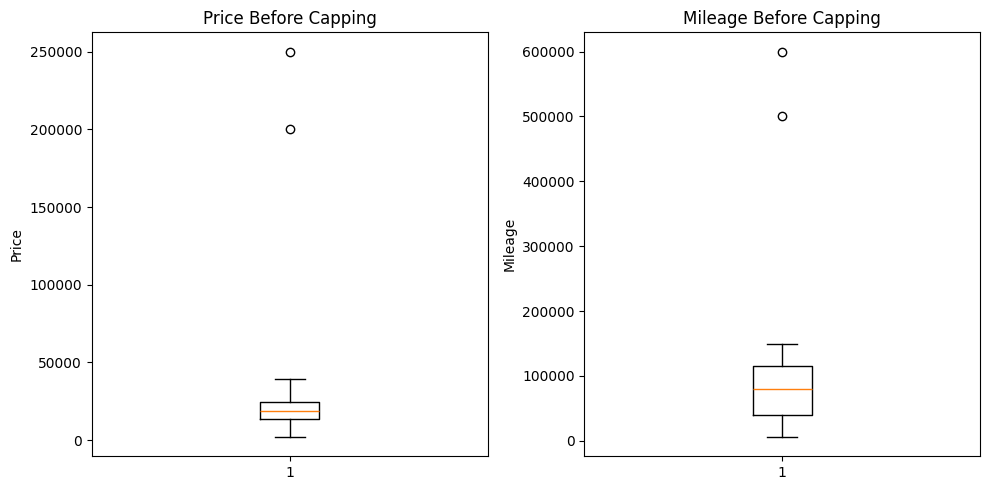

In [9]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.boxplot(
    clean["price"]
)

plt.title(
    "Price Before Capping"
)

plt.ylabel("Price")


plt.subplot(1, 2, 2)

plt.boxplot(
    clean["mileage_km"]
)

plt.title(
    "Mileage Before Capping"
)

plt.ylabel("Mileage")

plt.tight_layout()

plt.show()

In [10]:
def cap_outliers_iqr(
    df,
    col,
    k=1.5
):

    q1, q3 = df[
        col
    ].quantile(
        [0.25, 0.75]
    )

    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    n_outliers = (
        (df[col] < lower)
        |
        (df[col] > upper)
    ).sum()

    df[col] = df[
        col
    ].clip(
        lower,
        upper
    )

    return n_outliers

In [11]:
for col in [
    "price",
    "mileage_km"
]:

    count = cap_outliers_iqr(
        clean,
        col
    )

    print(
        f"{col}: "
        f"{count} outliers capped"
    )

price: 2 outliers capped
mileage_km: 2 outliers capped


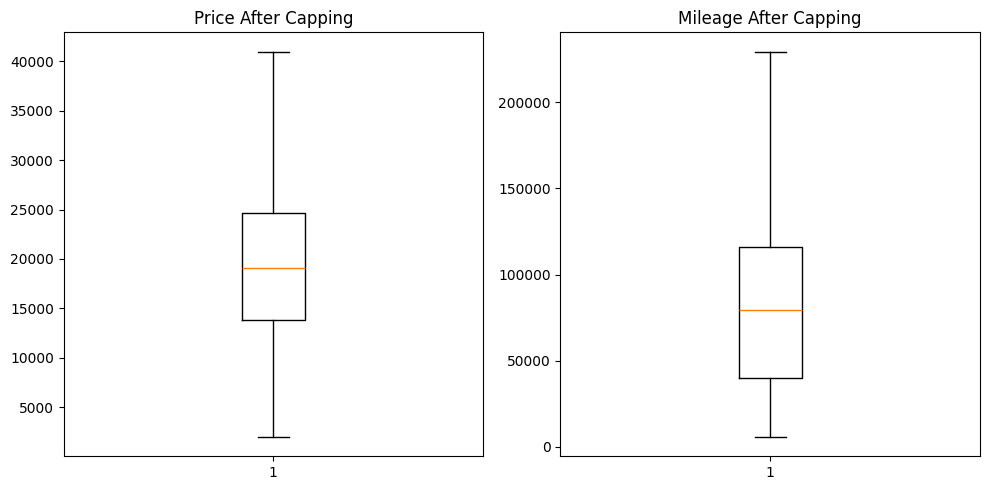

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.boxplot(
    clean["price"]
)

plt.title(
    "Price After Capping"
)


plt.subplot(1, 2, 2)

plt.boxplot(
    clean["mileage_km"]
)

plt.title(
    "Mileage After Capping"
)

plt.tight_layout()

plt.show()

In [13]:
encoder = OneHotEncoder(
    sparse_output=False,
    drop="first"
)

fuel_encoded = pd.DataFrame(
    encoder.fit_transform(
        clean[["fuel_type"]]
    ),
    columns=encoder.get_feature_names_out(
        ["fuel_type"]
    )
)

display(
    fuel_encoded.head()
)

,fuel_type_Electric,fuel_type_Petrol
0,1.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [14]:
scaler = StandardScaler()

scaled_num = pd.DataFrame(
    scaler.fit_transform(
        clean[num_cols]
    ),
    columns=num_cols
)

display(
    scaled_num.head()
)

,mileage_km,age_years,engine_size_L,price
0,-0.423806,-1.533807,-1.074970,2.884092
1,1.470920,0.065196,-0.684058,2.884092
2,3.432977,0.096132,-1.046182,-0.648142
3,3.432977,0.418800,-1.360992,-1.037162
4,-1.142406,0.714355,-1.247152,-0.633708


In [15]:
processed = pd.concat(
    [
        scaled_num,
        fuel_encoded
    ],
    axis=1
)

print(
    "Final model-ready dataset:"
)

display(
    processed.head()
)

print(
    "\nFinal shape:",
    processed.shape
)

Final model-ready dataset:


,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
0,-0.423806,-1.533807,-1.074970,2.884092,1.0,0.0
1,1.470920,0.065196,-0.684058,2.884092,0.0,0.0
2,3.432977,0.096132,-1.046182,-0.648142,0.0,0.0
3,3.432977,0.418800,-1.360992,-1.037162,0.0,0.0
4,-1.142406,0.714355,-1.247152,-0.633708,0.0,0.0



Final shape: (300, 6)
